<div style="background: linear-gradient(135deg, #0f172a, #1d4ed8); padding: 24px; border-radius: 16px; color: white; margin-bottom: 20px;">
<h1 style="margin: 0;">Análise exploratória — Base 3</h1>
<p style="margin-top: 10px;">Esta etapa investiga o comportamento temporal de PM2.5 em Aotizhongxin e suas relações observadas com as medições locais e das estações externas.</p>
</div>

**Objetivo:** produzir evidências descritivas antes da STL e da modelagem: evolução temporal, sazonalidade intradiária/semanal, distribuição, correlações, comportamento das estações externas, ausências e possíveis mudanças estruturais.

**Fonte de dados:** `01_dados/outputs/prepared_base3.csv`, gerada na Fase 2. As figuras são plotadas pelo código deste notebook; não são utilizadas imagens externas.

**Nota metodológica:** esta é uma análise exploratória descritiva. Ela pode utilizar a cobertura histórica completa para caracterizar a base, mas não define hiperparâmetros nem participa da seleção do teste final.

<div style="background:#eff6ff; border-left: 5px solid #2563eb; padding: 14px; border-radius: 8px; margin: 16px 0;">
<h2 style="margin-top:0; color:#1e3a8a;">1. Carregamento e escopo analítico</h2>
<p style="margin-bottom:0;">A análise mantém o alvo sem imputação. Para gráficos descritivos, cada estatística usa somente valores disponíveis; não são criados valores artificiais.</p>
</div>

In [29]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Image
from matplotlib_inline.backend_inline import set_matplotlib_formats

RANDOM_STATE = 42
TARGET = "target_pm25"
ROOT = Path.cwd().resolve()
while not (ROOT / "bases" / "grupo3").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("Raiz do repositório não encontrada.")
    ROOT = ROOT.parent

INPUT_PATH = ROOT / "analyses" / "grupo3" / "01_dados" / "outputs" / "prepared_base3.csv"
OUTPUT_DIR = ROOT / "analyses" / "grupo3" / "01_dados" / "outputs" / "eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

prepared = pd.read_csv(INPUT_PATH, parse_dates=["timestamp"])
prepared = prepared.sort_values("timestamp", kind="stable").set_index("timestamp")
prepared[TARGET] = pd.to_numeric(prepared[TARGET], errors="coerce")

if prepared.index.duplicated().any() or not prepared.index.is_monotonic_increasing:
    raise ValueError("A base preparada não está ordenada e única.")

sns.set_theme(style="whitegrid", palette="Blues")
print(f"Período: {prepared.index.min()} → {prepared.index.max()}")
print(f"Observações: {len(prepared):,}")
print(f"Ausências no alvo: {int(prepared[TARGET].isna().sum()):,}")


Período: 2013-03-01 00:00:00 → 2017-02-28 23:00:00
Observações: 35,064
Ausências no alvo: 925


<div style="background:#eff6ff; border-left: 5px solid #2563eb; padding: 14px; border-radius: 8px; margin: 16px 0;">
<h2 style="margin-top:0; color:#1e3a8a;">2. Evolução temporal e possíveis mudanças estruturais</h2>
<p style="margin-bottom:0;">A série horária é agregada por dia e por mês apenas para visualização. A agregação não altera a base usada nos modelos.</p>
</div>

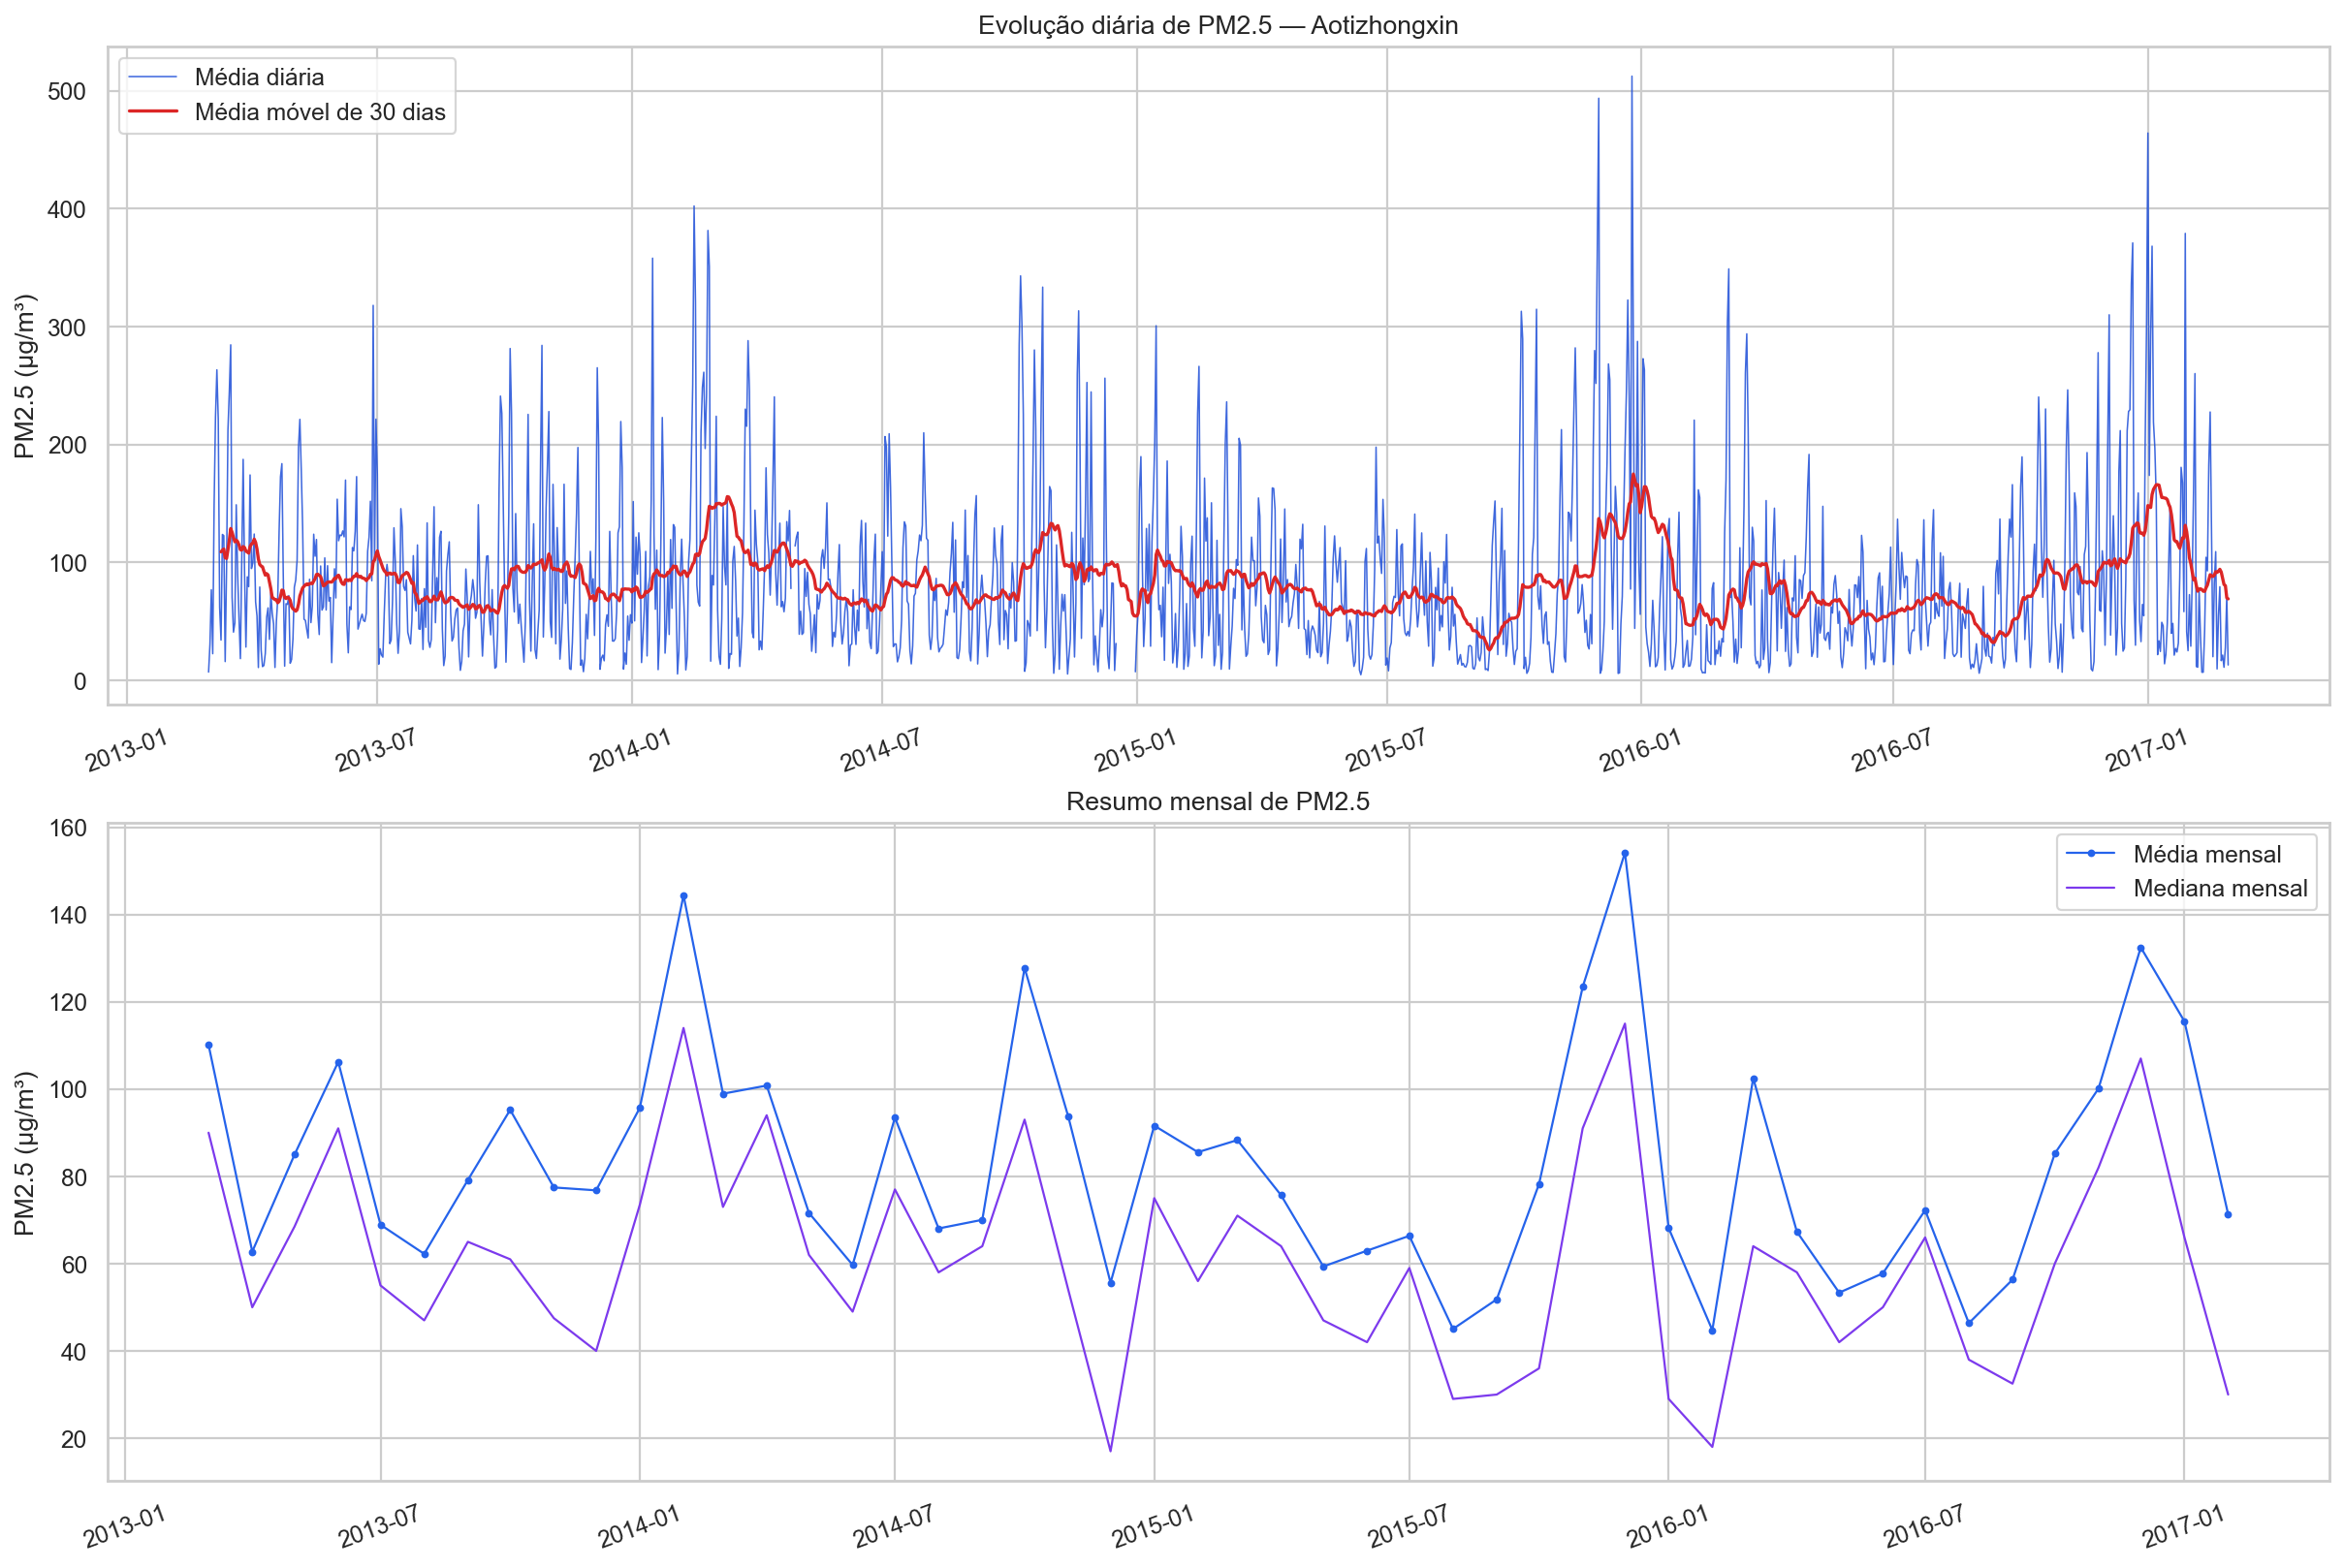

,timestamp,mean,median,max,count
0,2013-03-01,110.092742,90.0,463.0,744
1,2013-04-01,62.751389,50.0,263.0,720
2,2013-05-01,84.987871,68.5,665.0,742
3,2013-06-01,106.225941,91.0,510.0,717
4,2013-07-01,68.911290,55.0,271.0,744


In [30]:
target = prepared[TARGET]
daily = target.resample("D").agg(["mean", "median", "max", "count"])
monthly = target.resample("MS").agg(["mean", "median", "max", "count"])

fig, axes = plt.subplots(2, 1, figsize=(15, 10), constrained_layout=True)
axes[0].plot(daily.index, daily["mean"], color="#1d4ed8", linewidth=0.7, alpha=0.85, label="Média diária")
axes[0].plot(daily.index, daily["mean"].rolling(30, min_periods=10).mean(), color="#dc2626", linewidth=1.5, label="Média móvel de 30 dias")
axes[0].set_title("Evolução diária de PM2.5 — Aotizhongxin")
axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=20)
axes[1].plot(monthly.index, monthly["mean"], color="#2563eb", marker="o", markersize=2.5, linewidth=1, label="Média mensal")
axes[1].plot(monthly.index, monthly["median"], color="#7c3aed", linewidth=1, label="Mediana mensal")
axes[1].set_title("Resumo mensal de PM2.5")
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=20)
fig.savefig(OUTPUT_DIR / "evolucao_temporal_pm25.png", dpi=160, bbox_inches="tight")
display(Image(filename=str(OUTPUT_DIR / "evolucao_temporal_pm25.png")))
plt.close(fig)

monthly_summary = monthly.reset_index()
monthly_summary.to_csv(OUTPUT_DIR / "resumo_mensal_pm25.csv", index=False)
display(monthly_summary.head())


<div style="background:#eff6ff; border-left: 5px solid #2563eb; padding: 14px; border-radius: 8px; margin: 16px 0;">
<h2 style="margin-top:0; color:#1e3a8a;">3. Perfil intradiário e semanal</h2>
<p style="margin-bottom:0;">Os perfis são médias condicionais observadas por hora e dia da semana. Eles ajudam a identificar ciclos que serão avaliados formalmente na decomposição STL.</p>
</div>

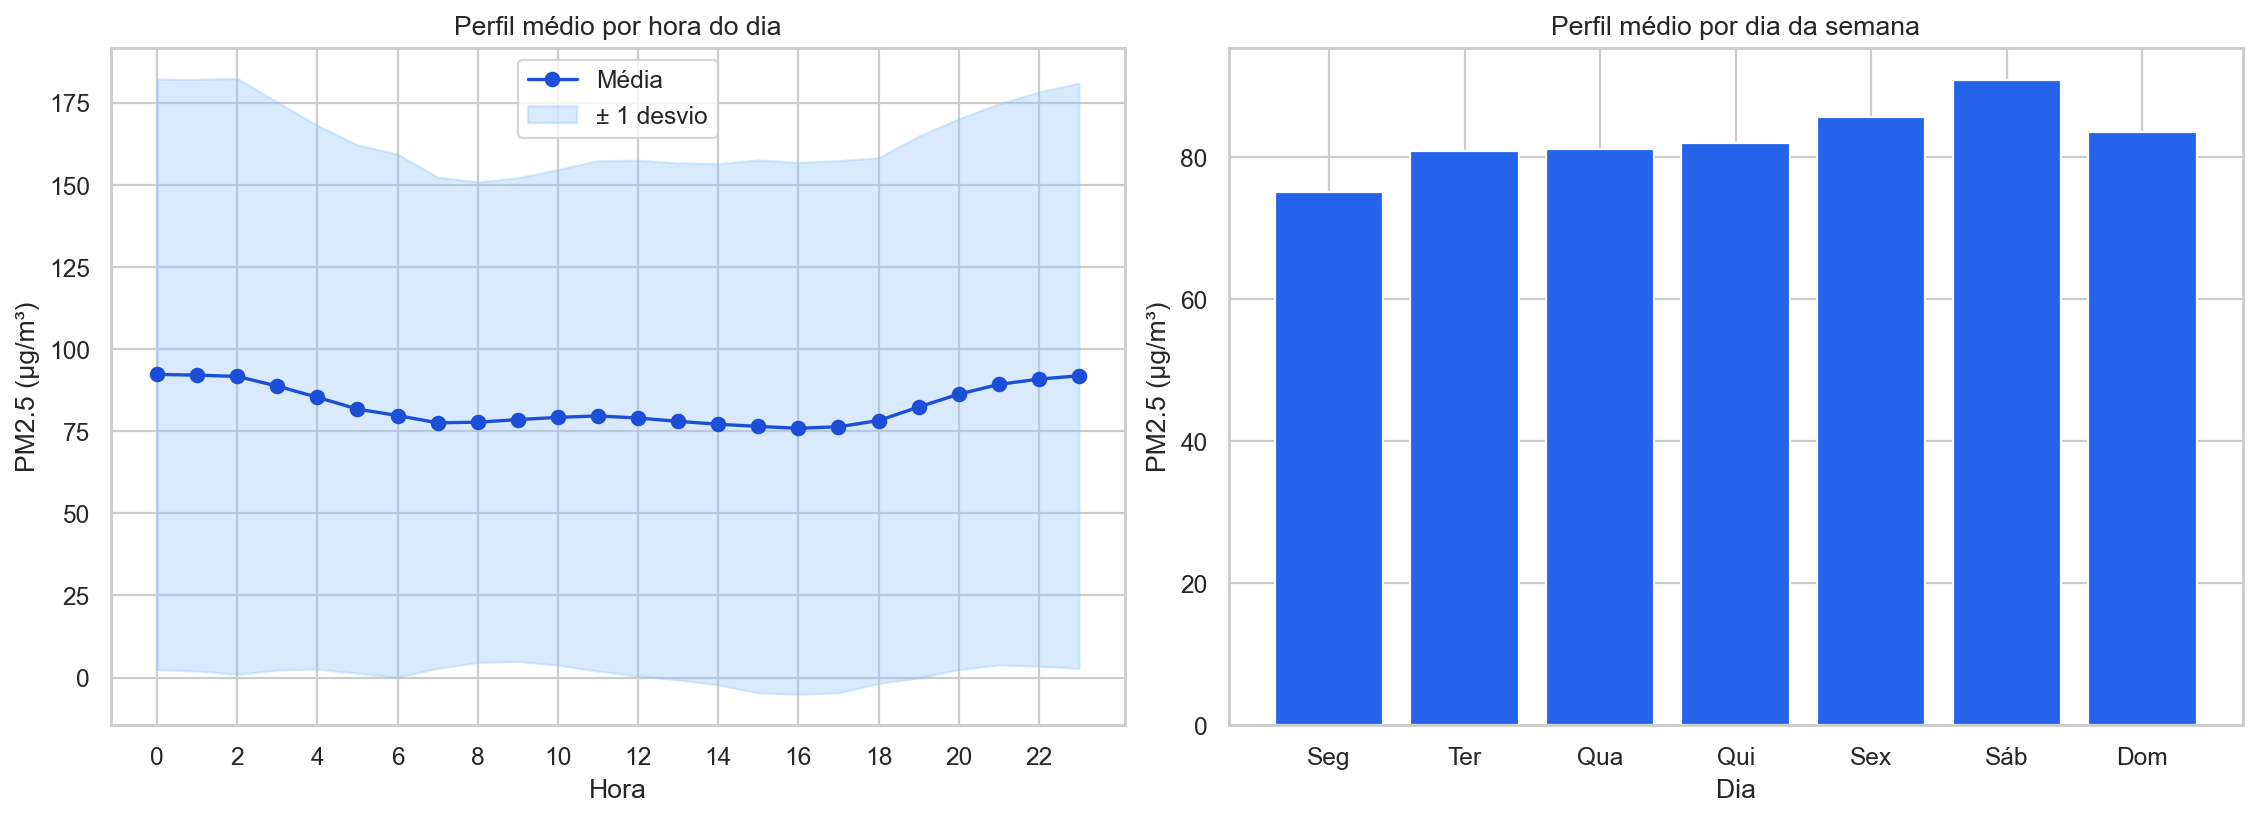

,mean,median,std,count
hour,,,,
0,92.301399,64.0,89.901147,1430
1,92.069279,65.0,90.085270,1429
2,91.687124,66.0,90.731710,1429
3,88.736613,66.0,86.491973,1423
4,85.336134,64.0,82.756440,1428
5,81.729091,60.5,80.457183,1430
6,79.775681,59.0,79.601898,1431
7,77.551927,57.0,74.781975,1427
8,77.742297,57.0,73.163328,1428


,mean,median,std,count
Seg,75.101072,53.0,75.879761,4851
Ter,80.859246,59.0,80.425691,4851
Qua,81.171661,58.0,80.165433,4859
Qui,82.043679,59.0,80.929696,4865
Sex,85.641127,60.0,84.057237,4914
Sáb,90.861094,65.0,89.712095,4917
Dom,83.589656,57.0,82.185419,4882


In [31]:
profile = pd.DataFrame({"pm25": target, "hour": target.index.hour, "dayofweek": target.index.dayofweek}).dropna()
hourly_profile = profile.groupby("hour")["pm25"].agg(["mean", "median", "std", "count"])
weekly_profile = profile.groupby("dayofweek")["pm25"].agg(["mean", "median", "std", "count"])
weekly_profile.index = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
axes[0].plot(hourly_profile.index, hourly_profile["mean"], marker="o", color="#1d4ed8", label="Média")
axes[0].fill_between(hourly_profile.index, hourly_profile["mean"] - hourly_profile["std"], hourly_profile["mean"] + hourly_profile["std"], color="#93c5fd", alpha=0.35, label="± 1 desvio")
axes[0].set_title("Perfil médio por hora do dia")
axes[0].set_xlabel("Hora")
axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()
axes[1].bar(weekly_profile.index, weekly_profile["mean"], color="#2563eb")
axes[1].set_title("Perfil médio por dia da semana")
axes[1].set_xlabel("Dia")
axes[1].set_ylabel("PM2.5 (µg/m³)")
fig.savefig(OUTPUT_DIR / "perfis_horario_semanal_pm25.png", dpi=160, bbox_inches="tight")
display(Image(filename=str(OUTPUT_DIR / "perfis_horario_semanal_pm25.png")))
plt.close(fig)

hourly_profile.to_csv(OUTPUT_DIR / "perfil_horario_pm25.csv")
weekly_profile.to_csv(OUTPUT_DIR / "perfil_semanal_pm25.csv")
display(hourly_profile)
display(weekly_profile)


<div style="background:#eff6ff; border-left: 5px solid #2563eb; padding: 14px; border-radius: 8px; margin: 16px 0;">
<h2 style="margin-top:0; color:#1e3a8a;">4. Distribuição, assimetria e variabilidade</h2>
<p style="margin-bottom:0;">O painel combina escala original e transformação logarítmica apenas para visualização. Nenhuma transformação do alvo é aplicada à base preparada ou aprovada para modelagem nesta fase.</p>
</div>

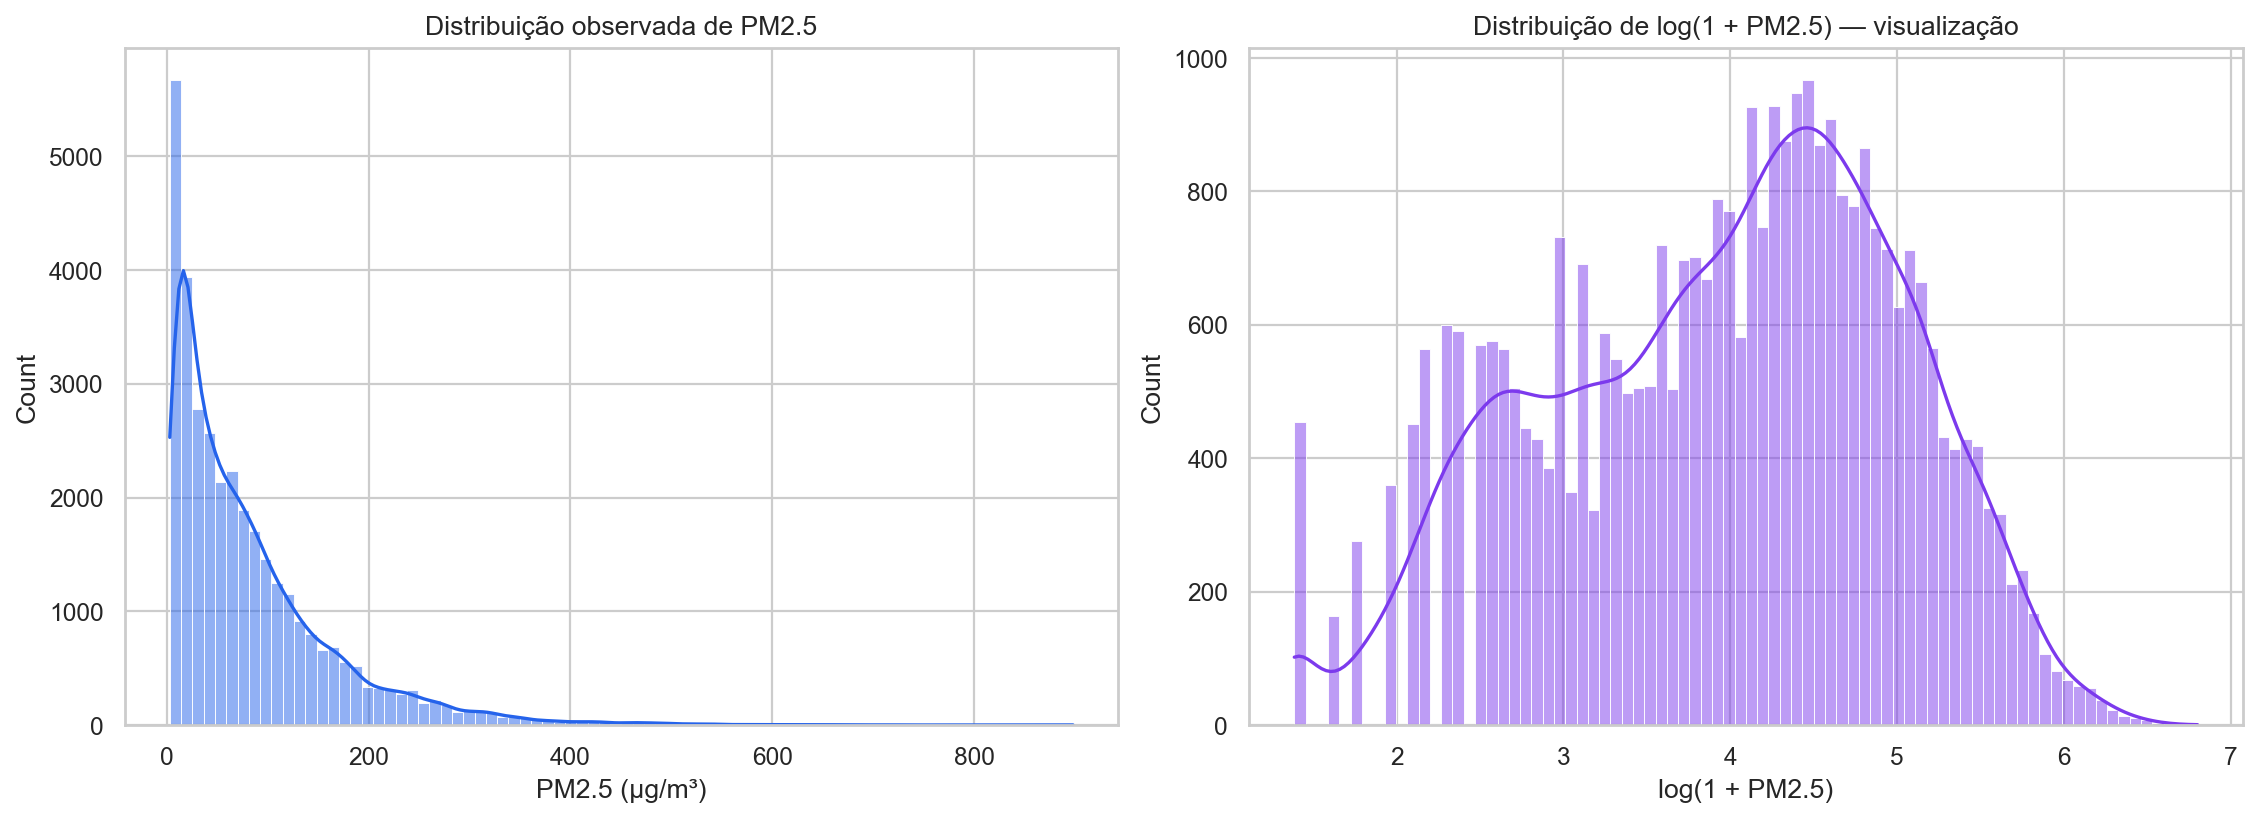

,PM2.5,skewness,missing
count,34139.000000,NaN,NaN
mean,82.773611,1.966068,925.0
std,82.135694,NaN,NaN
min,3.000000,NaN,NaN
1%,3.000000,NaN,NaN
5%,8.000000,NaN,NaN
25%,22.000000,NaN,NaN
50%,58.000000,NaN,NaN
75%,114.000000,NaN,NaN
95%,248.000000,NaN,NaN


In [32]:
target_available = target.dropna()
summary = target_available.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_frame("PM2.5")
summary["skewness"] = np.nan
summary.loc["mean", "skewness"] = target_available.skew()
summary.loc["mean", "missing"] = target.isna().sum()
summary.to_csv(OUTPUT_DIR / "resumo_distribuicao_pm25.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
sns.histplot(target_available, bins=80, kde=True, ax=axes[0], color="#2563eb")
axes[0].set_title("Distribuição observada de PM2.5")
axes[0].set_xlabel("PM2.5 (µg/m³)")
sns.histplot(np.log1p(target_available), bins=80, kde=True, ax=axes[1], color="#7c3aed")
axes[1].set_title("Distribuição de log(1 + PM2.5) — visualização")
axes[1].set_xlabel("log(1 + PM2.5)")
fig.savefig(OUTPUT_DIR / "distribuicao_pm25.png", dpi=160, bbox_inches="tight")
display(Image(filename=str(OUTPUT_DIR / "distribuicao_pm25.png")))
plt.close(fig)
display(summary)


<div style="background:#eff6ff; border-left: 5px solid #2563eb; padding: 14px; border-radius: 8px; margin: 16px 0;">
<h2 style="margin-top:0; color:#1e3a8a;">5. Relações com variáveis locais e estações externas</h2>
<p style="margin-bottom:0;">As correlações abaixo são exploratórias e contemporâneas; não representam automaticamente relações válidas para previsão. A modelagem usará as versões defasadas definidas na Fase 3.</p>
</div>

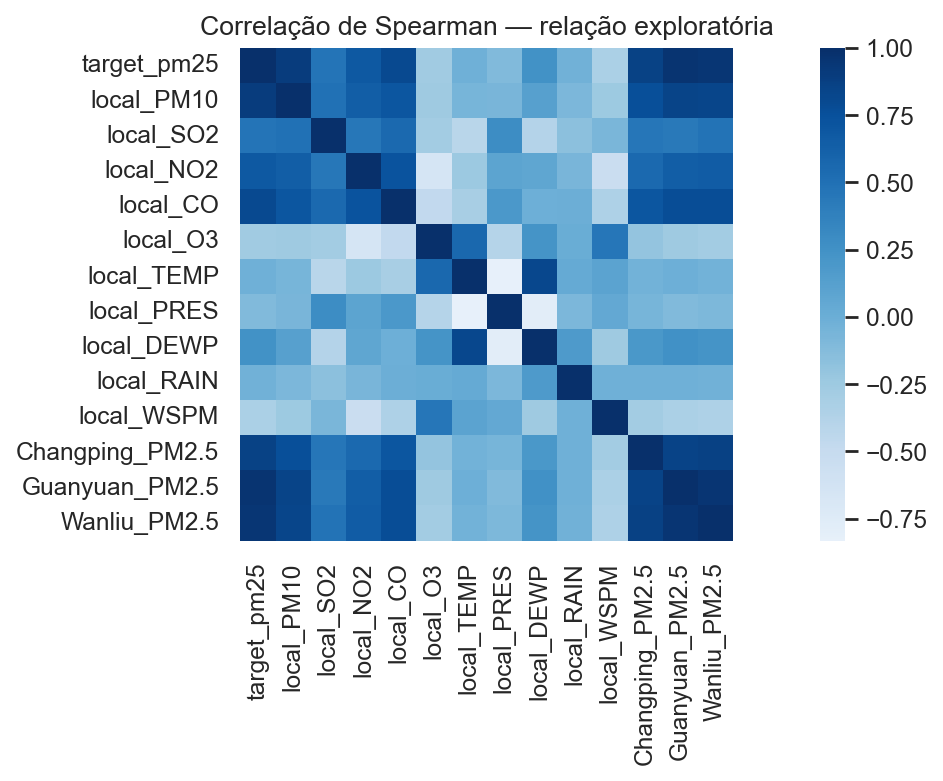

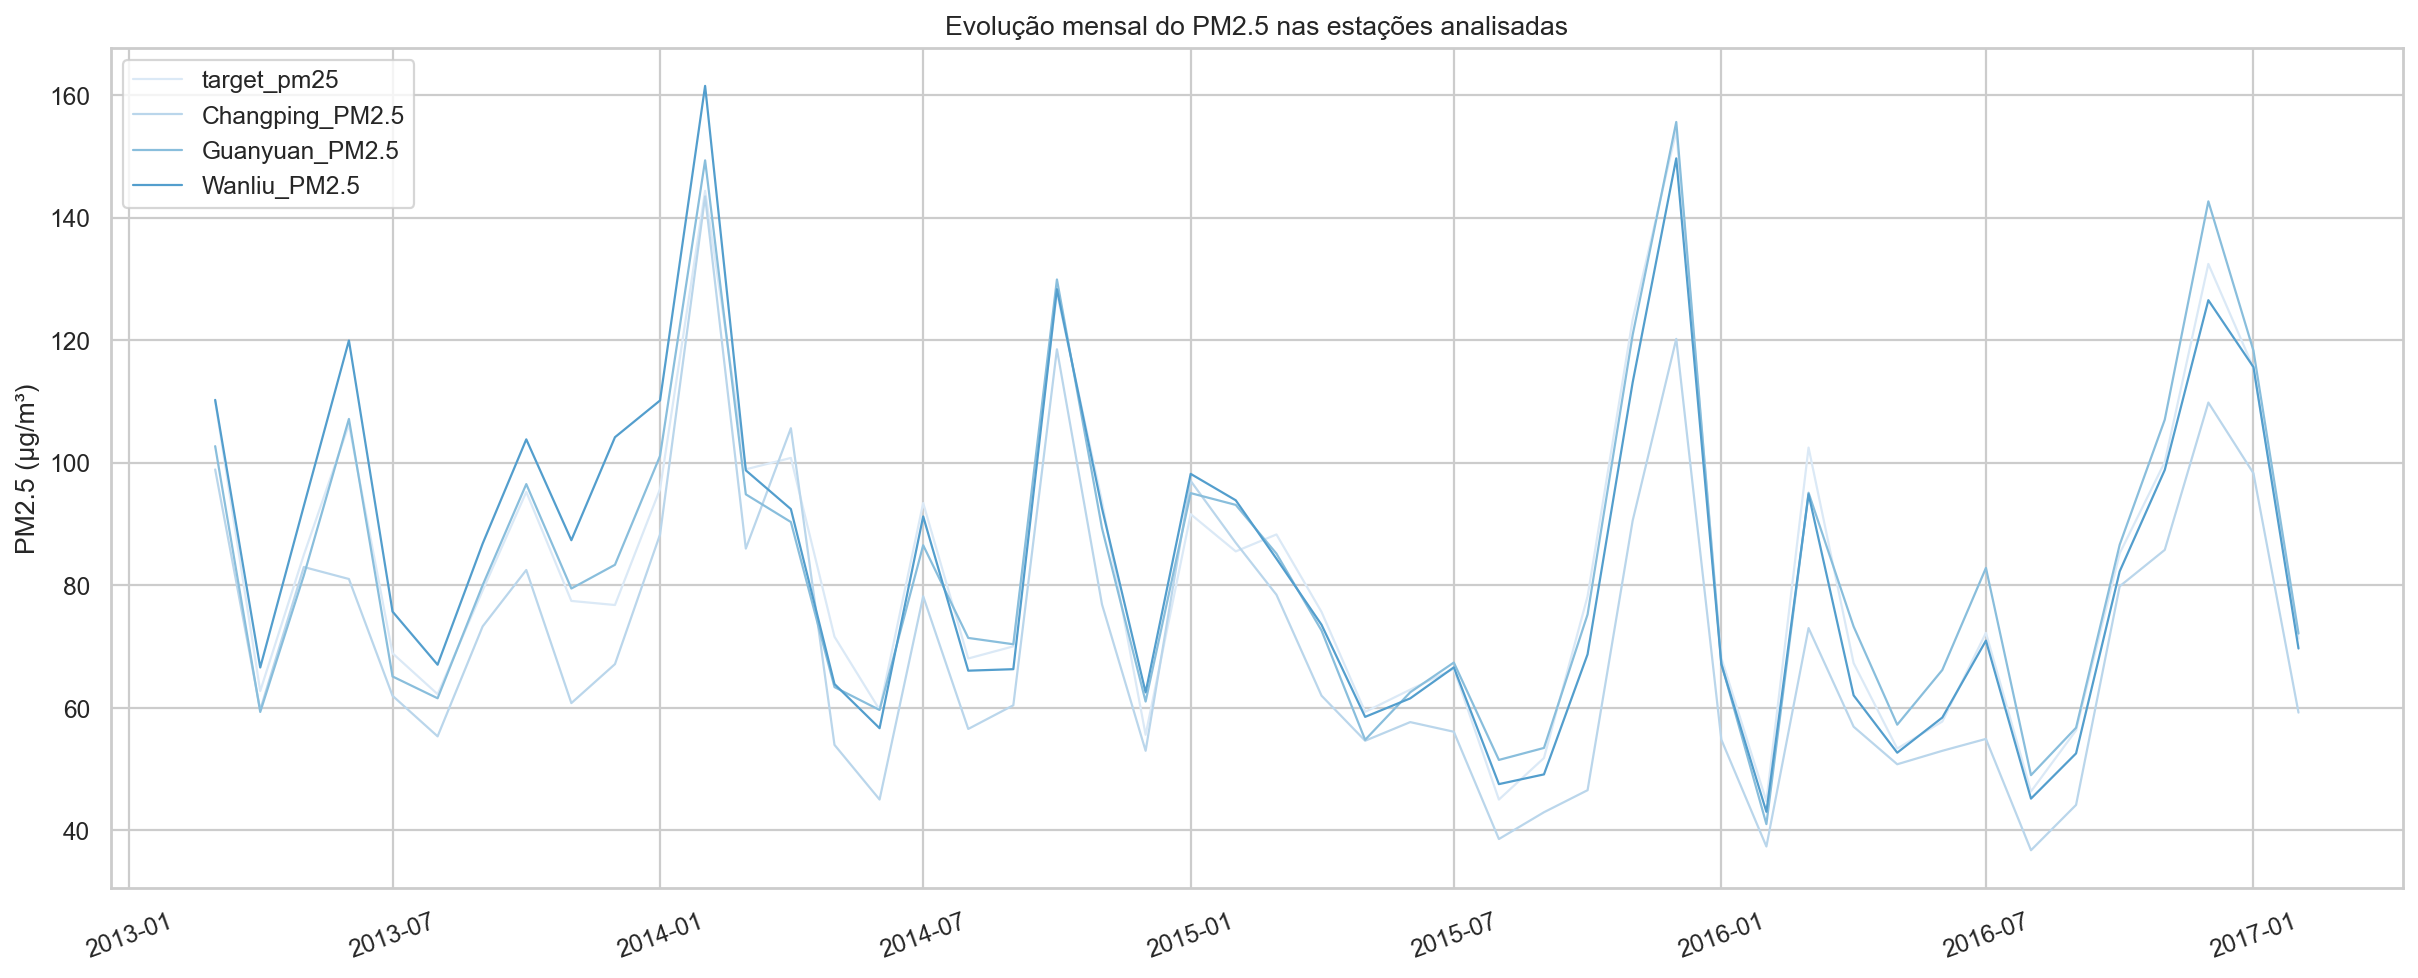

,spearman_com_alvo
target_pm25,1.000000
Guanyuan_PM2.5,0.959770
Wanliu_PM2.5,0.949637
local_PM10,0.894750
Changping_PM2.5,0.863835
local_CO,0.802657
local_NO2,0.682909
local_SO2,0.471431
local_DEWP,0.248092
local_TEMP,-0.016922


In [33]:
numeric_columns = [
    column for column in prepared.columns
    if column not in {"target_pm25"} and not column.endswith("_missing_raw")
    and pd.api.types.is_numeric_dtype(prepared[column])
]
selected_external = [
    "local_PM10", "local_SO2", "local_NO2", "local_CO", "local_O3", "local_TEMP", "local_PRES", "local_DEWP", "local_RAIN", "local_WSPM",
    "Changping_PM2.5", "Guanyuan_PM2.5", "Wanliu_PM2.5",
]
selected_external = [column for column in selected_external if column in prepared.columns]
correlation_columns = [TARGET] + selected_external
correlation = prepared[correlation_columns].corr(method="spearman")
correlation.to_csv(OUTPUT_DIR / "correlacao_spearman_exploratoria.csv")

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(correlation, cmap="Blues", center=0, annot=False, square=True, ax=ax)
ax.set_title("Correlação de Spearman — relação exploratória")
fig.savefig(OUTPUT_DIR / "heatmap_correlacao_spearman.png", dpi=160, bbox_inches="tight")
display(Image(filename=str(OUTPUT_DIR / "heatmap_correlacao_spearman.png")))
plt.close(fig)

external_monthly = prepared[[column for column in [TARGET, "Changping_PM2.5", "Guanyuan_PM2.5", "Wanliu_PM2.5"] if column in prepared.columns]].resample("MS").mean()
fig, ax = plt.subplots(figsize=(15, 6), constrained_layout=True)
for column in external_monthly.columns:
    ax.plot(external_monthly.index, external_monthly[column], linewidth=1.0, label=column)
ax.set_title("Evolução mensal do PM2.5 nas estações analisadas")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend()
ax.tick_params(axis="x", rotation=20)
fig.savefig(OUTPUT_DIR / "comparacao_mensal_estacoes_pm25.png", dpi=160, bbox_inches="tight")
display(Image(filename=str(OUTPUT_DIR / "comparacao_mensal_estacoes_pm25.png")))
plt.close(fig)

display(correlation[TARGET].sort_values(ascending=False).to_frame("spearman_com_alvo"))


<div style="background:#eff6ff; border-left: 5px solid #2563eb; padding: 14px; border-radius: 8px; margin: 16px 0;">
<h2 style="margin-top:0; color:#1e3a8a;">6. Ausências e mudanças de disponibilidade</h2>
<p style="margin-bottom:0;">Os indicadores <code>_missing_raw</code> da Fase 2 permitem localizar períodos com ausência sem confundir imputação causal com observação original.</p>
</div>

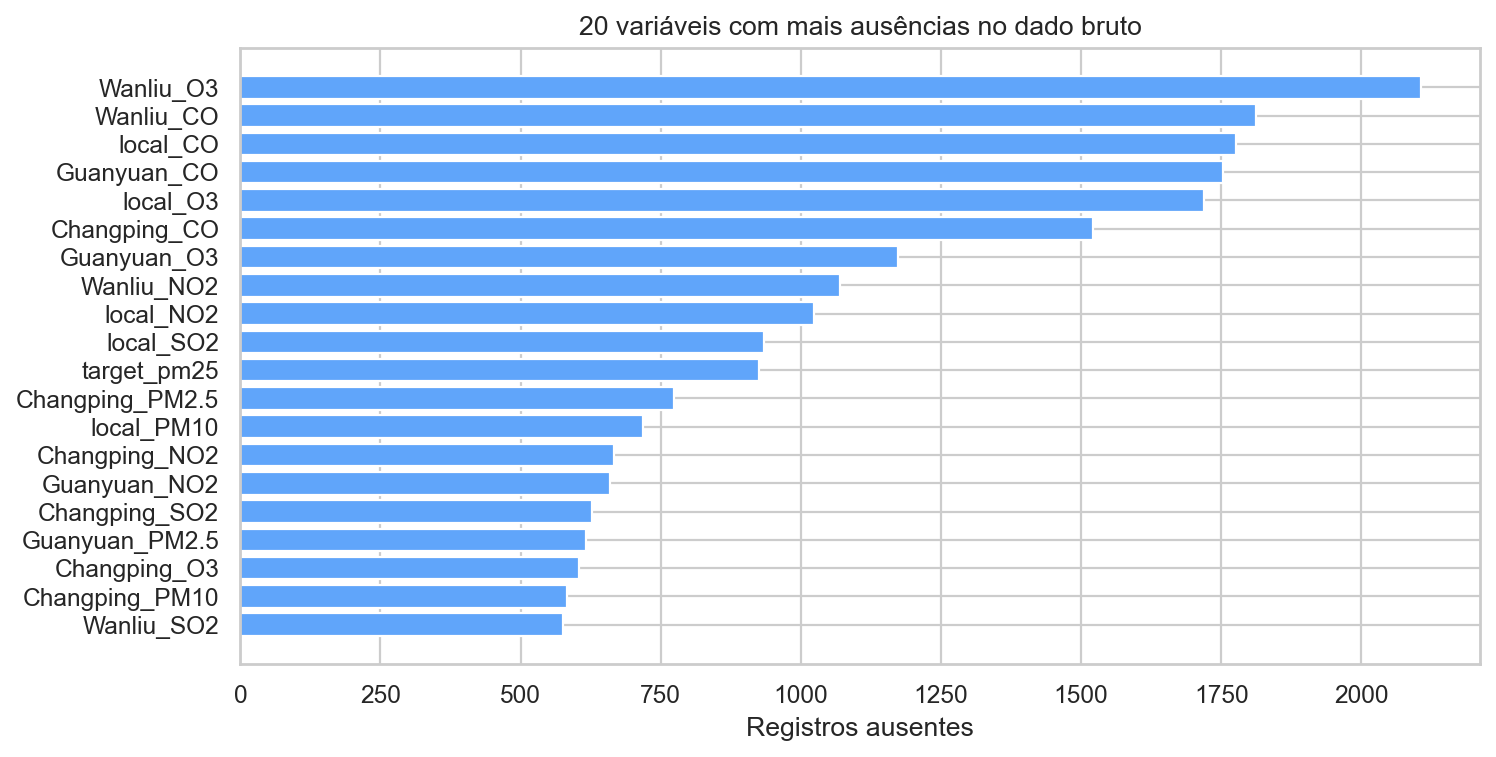

,variavel,ausencias,percentual
41,Wanliu_O3,2107,6.009012
40,Wanliu_CO,1812,5.167693
4,local_CO,1776,5.065024
28,Guanyuan_CO,1753,4.999430
5,local_O3,1719,4.902464
16,Changping_CO,1521,4.337782
29,Guanyuan_O3,1173,3.345311
39,Wanliu_NO2,1070,3.051563
3,local_NO2,1023,2.917522
2,local_SO2,935,2.666553


In [34]:
missing_columns = [column for column in prepared.columns if column.endswith("_missing_raw")]
missing_summary = pd.DataFrame({
    "variavel": [column.removesuffix("_missing_raw") for column in missing_columns],
    "ausencias": [int(prepared[column].sum()) for column in missing_columns],
})
missing_summary["percentual"] = 100 * missing_summary["ausencias"] / len(prepared)
missing_summary = missing_summary.sort_values("ausencias", ascending=False)
missing_summary.to_csv(OUTPUT_DIR / "resumo_ausencias_brutas.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
top_missing = missing_summary.head(20).sort_values("ausencias")
ax.barh(top_missing["variavel"], top_missing["ausencias"], color="#60a5fa")
ax.set_title("20 variáveis com mais ausências no dado bruto")
ax.set_xlabel("Registros ausentes")
fig.savefig(OUTPUT_DIR / "ausencias_brutas_top20.png", dpi=160, bbox_inches="tight")
display(Image(filename=str(OUTPUT_DIR / "ausencias_brutas_top20.png")))
plt.close(fig)

display(missing_summary.head(20))


<div style="background:#dbeafe; border-radius: 12px; padding: 16px; color:#1e3a8a;">
<h2 style="margin-top:0;">Síntese exploratória</h2>
<p>Os valores efetivos desta síntese são produzidos na execução e salvos em CSV. Este notebook não transforma os dados nem conclui qual modelo é superior.</p>
<ul style="margin-bottom:0;">
<li>A evolução diária/mensal identifica tendência e variação de escala que serão aprofundadas pela STL.</li>
<li>Os perfis horário e semanal ajudam a justificar a investigação de sazonalidade.</li>
<li>As correlações são descritivas; para previsão, somente as features defasadas da Fase 3 são elegíveis.</li>
<li>Ausências e extremos são reportados, mas não removidos nesta etapa.</li>
</ul>
</div>

In [35]:
eda_manifest = {
    "input_file": str(INPUT_PATH.relative_to(ROOT)),
    "output_directory": str(OUTPUT_DIR.relative_to(ROOT)),
    "target": TARGET,
    "observations": int(len(prepared)),
    "target_missing": int(target.isna().sum()),
    "plots_generated_by_code": True,
    "external_images_used": False,
    "analysis_scope": [
        "evolução diária e mensal",
        "perfil intradiário e semanal",
        "distribuição e assimetria",
        "correlações exploratórias",
        "comparação mensal das estações",
        "ausências brutas",
    ],
}
with (OUTPUT_DIR / "eda_manifest.json").open("w", encoding="utf-8") as file:
    json.dump(eda_manifest, file, ensure_ascii=False, indent=2)
print(json.dumps(eda_manifest, ensure_ascii=False, indent=2))


{
  "input_file": "analyses/grupo3/01_dados/outputs/prepared_base3.csv",
  "output_directory": "analyses/grupo3/01_dados/outputs/eda",
  "target": "target_pm25",
  "observations": 35064,
  "target_missing": 925,
  "plots_generated_by_code": true,
  "external_images_used": false,
  "analysis_scope": [
    "evolução diária e mensal",
    "perfil intradiário e semanal",
    "distribuição e assimetria",
    "correlações exploratórias",
    "comparação mensal das estações",
    "ausências brutas"
  ]
}
